In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import defaultdict

In [2]:
# Read "Discharge Means.csv" created from "Discharge Temp Requests v3.ipynb"
source = pd.read_csv("Discharge Means.csv")
source

,date,monitoring_location_id,parameter_code,value (ft^3/s),day_of_year
0,2008-12-05,USGS-01193050,60.0,22627.343750,340
1,2008-12-06,USGS-01193050,60.0,19779.427083,341
2,2008-12-07,USGS-01193050,60.0,18323.645833,342
3,2008-12-08,USGS-01193050,60.0,17286.770833,343
4,2008-12-10,USGS-01193050,60.0,16372.089429,345
...,...,...,...,...,...
38764,2026-05-31,USGS-01170500,60.0,23092.708333,151
38765,2026-06-01,USGS-01170500,60.0,25543.750000,152
38766,2026-06-02,USGS-01170500,60.0,19800.000000,153
38767,2026-06-05,USGS-01170500,60.0,11355.961538,156


In [3]:
# Get all USGS IDs in the dataframe just cause I'm lazy
locations = source["monitoring_location_id"].unique()
locations

<StringArray>
['USGS-01193050', 'USGS-01184000', 'USGS-01172010', 'USGS-01170500']
Length: 4, dtype: str

In [4]:
thom = source[source["monitoring_location_id"] == "USGS-01184000"]
thom.reset_index(drop=True, inplace=True)
thom

,date,monitoring_location_id,parameter_code,value (ft^3/s),day_of_year
0,1990-10-01,USGS-01184000,60.0,7418.021978,274
1,1990-10-02,USGS-01184000,60.0,9582.291667,275
2,1990-10-03,USGS-01184000,60.0,8464.687500,276
3,1990-10-04,USGS-01184000,60.0,8350.416667,277
4,1990-10-05,USGS-01184000,60.0,9809.270833,278
...,...,...,...,...,...
12218,2026-06-03,USGS-01184000,60.0,17996.875000,154
12219,2026-06-04,USGS-01184000,60.0,14780.208333,155
12220,2026-06-05,USGS-01184000,60.0,12135.416667,156
12221,2026-06-06,USGS-01184000,60.0,11042.291667,157


In [5]:
holyoke = source[source["monitoring_location_id"] == "USGS-01172010"]
holyoke.reset_index(drop=True, inplace=True)
holyoke

,date,monitoring_location_id,parameter_code,value (ft^3/s),day_of_year
0,2002-11-02,USGS-01172010,60.0,5427.291667,306
1,2002-11-03,USGS-01172010,60.0,4142.604167,307
2,2002-11-04,USGS-01172010,60.0,3737.865169,308
3,2002-11-05,USGS-01172010,60.0,4888.125000,309
4,2002-11-06,USGS-01172010,60.0,6253.125000,310
...,...,...,...,...,...
8304,2026-06-03,USGS-01172010,60.0,16507.291667,154
8305,2026-06-04,USGS-01172010,60.0,13433.333333,155
8306,2026-06-05,USGS-01172010,60.0,10663.958333,156
8307,2026-06-06,USGS-01172010,60.0,9847.812500,157


In [6]:
montague = source[source["monitoring_location_id"] == "USGS-01170500"]
montague.reset_index(drop=True, inplace=True)
montague

,date,monitoring_location_id,parameter_code,value (ft^3/s),day_of_year
0,1993-04-18,USGS-01170500,60.0,78246.739130,108
1,1993-04-19,USGS-01170500,60.0,73864.583333,109
2,1993-04-20,USGS-01170500,60.0,66491.666667,110
3,1993-04-21,USGS-01170500,60.0,61608.333333,111
4,1993-04-22,USGS-01170500,60.0,57927.083333,112
...,...,...,...,...,...
11916,2026-05-31,USGS-01170500,60.0,23092.708333,151
11917,2026-06-01,USGS-01170500,60.0,25543.750000,152
11918,2026-06-02,USGS-01170500,60.0,19800.000000,153
11919,2026-06-05,USGS-01170500,60.0,11355.961538,156


In [7]:
# Need to remind Pandas that these columns are of type datetime
thom["date"] = pd.to_datetime(thom["date"])
holyoke["date"] = pd.to_datetime(holyoke["date"])
montague["date"] = pd.to_datetime(montague["date"])

In [8]:
# Create and populate a year column from the date column
thom["year"] = thom["date"].dt.year
holyoke["year"] = holyoke["date"].dt.year
montague["year"] = montague["date"].dt.year

In [ ]:
# We are concerned right now with the period of time from day 108 to 181 as these are our Shad run dates
trimmed_thom = thom[thom["day_of_year"].between(108, 181, inclusive="both")].copy()
trimmed_holyoke = holyoke[holyoke["day_of_year"].between(108, 181, inclusive="both")].copy()
trimmed_montague = montague[montague["day_of_year"].between(108, 181, inclusive="both")].copy()

In [12]:
# We're going to pivot the dataframe to access the data in an easier way for how we're going to use it
p_thom = trimmed_thom.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_thom.drop(p_thom.index[-1], inplace=True)
p_thom

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
1991,26454.166667,25344.791667,26530.208333,26098.958333,44891.666667,64133.333333,57056.250000,43322.916667,33687.500000,29982.291667,...,10193.750000,8909.895833,6047.604167,5143.473684,6087.604167,4874.479167,5188.229167,5763.333333,6351.979167,4492.083333
1992,22163.541667,25539.583333,26717.708333,25784.375000,31464.583333,48255.208333,57490.625000,60123.958333,66087.500000,72626.041667,...,7251.041667,7200.000000,7178.125000,8248.854167,7347.708333,11404.479167,9828.750000,8668.645833,8168.437500,6408.958333
1993,97311.458333,96903.125000,88170.833333,80172.916667,73582.291667,80556.250000,83636.458333,70541.666667,58420.833333,62353.125000,...,6446.562500,10547.291667,11777.083333,11591.666667,11516.666667,10251.145833,6923.541667,5935.312500,8464.166667,7644.270833
1994,103333.333333,103177.083333,97148.958333,85778.125000,75041.666667,56588.541667,45056.250000,40522.916667,39544.791667,42488.541667,...,9730.000000,NaN,11014.021739,10351.979167,9730.000000,NaN,NaN,9792.717391,9900.104167,11182.395833
1996,95259.375000,105023.958333,86500.000000,80794.791667,71922.916667,71909.375000,82377.083333,92075.000000,102184.375000,99475.000000,...,15130.526316,14720.833333,11716.041667,8185.520833,11387.291667,14592.708333,11532.812500,13162.765957,13705.208333,11619.479167
1997,37781.250000,52304.166667,73268.750000,75154.166667,72280.208333,66762.500000,53192.708333,46025.000000,40422.916667,37289.583333,...,14740.625000,11516.041667,10011.770833,11565.312500,13134.375000,13948.958333,13288.541667,9510.729167,5959.895833,6301.145833
1998,22894.791667,23917.708333,24684.375000,31823.958333,32628.125000,27285.416667,23601.041667,20992.708333,20693.750000,19491.666667,...,47144.791667,35468.750000,28467.708333,24807.291667,22550.000000,19482.291667,24727.083333,44955.208333,46006.250000,32284.375000
1999,17046.875000,17683.333333,16895.833333,16388.541667,16103.125000,15104.166667,16494.791667,15126.041667,11604.166667,12505.208333,...,3243.333333,3531.354167,3471.875000,3376.250000,3402.916667,3466.979167,3462.187500,3188.437500,6324.895833,8970.000000
2000,33485.416667,31469.791667,31116.666667,28539.583333,25887.500000,39798.958333,50696.875000,52475.000000,54079.166667,47690.625000,...,15872.916667,16303.125000,14741.666667,13338.541667,12596.666667,8185.416667,9768.020833,14763.541667,15987.500000,15513.541667


In [13]:
p_holyoke = trimmed_holyoke.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_holyoke.drop(p_holyoke.index[-1], inplace=True)
p_holyoke

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
2003,44767.708333,35720.833333,26439.583333,24260.416667,25404.166667,28822.916667,29393.750000,27452.083333,24318.750000,29253.125000,...,8436.145833,9149.062500,13765.625000,12034.791667,9744.583333,8433.854167,7619.479167,7188.958333,4371.666667,4797.187500
2004,44075.268817,34662.365591,31929.032258,31637.894737,28919.791667,29328.723404,27743.617021,27819.512195,26129.032258,26586.170213,...,4716.086957,5114.130435,5793.043478,4775.978261,5469.456522,5486.304348,6077.173913,4780.638298,4030.000000,3701.157895
2005,24184.375000,21853.125000,21989.583333,25014.583333,26820.833333,30713.541667,44254.166667,65293.750000,64697.916667,56226.041667,...,30237.500000,22550.000000,15896.875000,13496.875000,8360.312500,8662.500000,8656.562500,7809.270833,10081.250000,16007.291667
2006,16003.125000,15425.000000,15201.041667,13713.541667,11698.958333,13358.333333,17573.958333,21581.250000,22427.083333,19705.208333,...,15662.500000,14102.083333,15977.083333,14459.375000,13731.250000,15420.833333,21667.708333,36635.416667,43938.541667,47962.500000
2007,91297.916667,83383.333333,80386.458333,82795.833333,79887.500000,76438.541667,76026.041667,77206.250000,73088.541667,62869.791667,...,5453.854167,4761.250000,4676.458333,3802.708333,4273.854167,5739.270833,4947.083333,5489.583333,3563.229167,2551.145833
2008,61877.083333,58945.833333,59030.208333,62378.125000,65620.833333,64803.125000,57789.583333,51501.041667,46656.250000,44285.416667,...,10562.916667,8787.500000,9641.562500,9817.187500,16816.666667,13673.958333,12570.833333,11346.875000,8240.937500,11331.562500
2009,18629.166667,17941.666667,17865.625000,22055.208333,23853.125000,23604.166667,24858.333333,28360.416667,26752.083333,25538.541667,...,23308.333333,19205.208333,16015.625000,13596.875000,11276.979167,11464.583333,11337.500000,12325.000000,12816.666667,15176.041667
2010,27172.916667,29050.000000,25778.125000,25031.250000,21829.166667,19080.208333,16055.208333,15926.041667,15686.458333,16240.625000,...,6130.833333,6376.458333,6387.812500,8235.833333,7477.812500,5441.458333,5632.083333,6100.312500,9826.979167,12391.666667
2011,77596.875000,69273.958333,61212.500000,54434.375000,51850.000000,48116.666667,45275.000000,42790.625000,43985.416667,55505.208333,...,9070.104167,9551.770833,15113.854167,26597.916667,29361.458333,27526.041667,24368.750000,19566.666667,18266.666667,15019.791667


In [14]:
p_montague = trimmed_montague.pivot(index="year", columns="day_of_year", values="value (ft^3/s)")
p_montague.drop(p_montague.index[-1], inplace=True)
p_montague

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
1993,78246.739130,73864.583333,66491.666667,61608.333333,57927.083333,67756.250000,61511.458333,48800.000000,47564.583333,50891.666667,...,8202.291667,9313.854167,10735.520833,10377.812500,10910.104167,6319.270833,3839.687500,7680.729167,6977.812500,5906.875000
1994,91360.416667,86658.333333,76814.583333,69665.625000,55725.000000,41534.375000,37268.750000,34246.875000,39379.166667,33966.666667,...,5961.354167,7855.104167,7922.291667,4544.270833,5124.270833,5458.229167,6962.708333,6821.354167,7327.083333,9270.833333
1995,10130.416667,9983.958333,10236.354167,11860.416667,9756.666667,12930.000000,15058.333333,13892.708333,9851.666667,10141.250000,...,2684.270833,2575.312500,2443.333333,2075.416667,2217.187500,2851.041667,2400.937500,2361.562500,2231.875000,2383.333333
1996,89466.666667,74354.166667,65339.583333,60461.458333,55756.250000,63067.708333,73295.833333,82175.000000,88276.041667,78985.416667,...,11668.020833,8891.562500,4976.458333,7592.708333,12971.979167,9902.916667,11480.208333,12412.083333,11604.791667,7939.895833
1997,36855.208333,52796.875000,63355.208333,59711.458333,58800.000000,49392.708333,40780.208333,37033.333333,33480.208333,32938.541667,...,11374.166667,7090.104167,9593.125000,9835.520833,12307.812500,10852.187500,8854.687500,4079.583333,4308.229167,5493.958333
1998,21139.583333,18277.083333,23372.916667,30383.333333,25515.625000,21336.458333,18016.666667,16671.875000,17173.958333,15895.833333,...,36762.500000,28258.333333,23043.750000,21627.083333,16169.791667,18565.625000,35309.375000,49609.375000,32048.958333,25310.416667
1999,16510.416667,17061.458333,16397.916667,16518.750000,15231.250000,15818.750000,15686.458333,11917.812500,11575.833333,11052.812500,...,3096.666667,2489.375000,2422.187500,2427.708333,2421.979167,2782.187500,1892.395833,4908.958333,7966.562500,6682.812500
2000,30871.875000,30441.666667,29832.291667,25319.791667,26889.583333,38938.541667,43059.375000,47094.791667,44594.791667,39789.583333,...,13446.875000,13702.083333,10680.729167,10315.208333,5329.166667,4907.291667,12156.354167,13288.229167,14214.583333,12502.291667
2001,60773.958333,53639.583333,51587.500000,49323.958333,62739.583333,85802.083333,88260.416667,87039.583333,82996.875000,82120.833333,...,10992.291667,7016.979167,5686.875000,5294.895833,6663.437500,6924.270833,4880.312500,4308.229167,3069.375000,4476.666667


In [15]:
thom_means = p_thom.mean(axis=0)
thom_means

day_of_year
108    49089.157475
109    47517.316176
110    44856.210172
111    42992.260546
112    41769.145221
           ...     
177    12458.563763
178    12604.734848
179    13579.585295
180    14552.162990
181    14195.239899
Length: 74, dtype: float64

In [16]:
holyoke_means = p_holyoke.mean(axis=0)
holyoke_means

day_of_year
108    41713.295202
109    38823.893613
110    36353.599229
111    35290.864083
112    34197.590580
           ...     
177    10979.114682
178    11345.017525
179    11891.019600
180    12938.315217
181    13494.447988
Length: 74, dtype: float64

In [17]:
montague_means = p_montague.mean(axis=0)
montague_means

day_of_year
108    42753.570086
109    39739.580177
110    38037.143308
111    36654.835859
112    35554.450758
           ...     
177    10270.808591
178    11596.461490
179    12268.425697
180    12616.341146
181    12246.497396
Length: 74, dtype: float64

In [18]:
thom_anoms = (p_thom.copy() - thom_means)/thom_means
thom_anoms

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
1991,-0.461100,-0.466620,-4.085499e-01,-0.392938,0.074757,0.498913,0.311977,0.005298,-0.182026,-0.250960,...,-0.225926,-0.288501,-0.496338,-0.575544,-0.504405,-0.608745,-0.588390,-0.575588,-0.563503,-0.683550
1992,-0.548504,-0.462521,-4.043699e-01,-0.400255,-0.246703,0.127812,0.321965,0.395162,0.604686,0.814398,...,-0.449384,-0.425045,-0.402184,-0.319278,-0.401820,-0.084607,-0.220233,-0.361641,-0.438679,-0.548514
1993,0.982341,1.039322,9.656327e-01,0.864822,0.761642,0.882746,0.923174,0.636903,0.418530,0.557752,...,-0.510473,-0.157747,-0.019170,-0.043418,-0.062423,-0.177181,-0.450719,-0.562924,-0.418357,-0.461491
1994,1.105013,1.171358,1.165786e+00,0.995199,0.796581,0.322577,0.036043,-0.059675,-0.039804,0.061480,...,-0.261141,NaN,-0.082720,-0.145721,-0.207876,NaN,NaN,-0.278865,-0.319682,-0.212243
1996,0.940538,1.210225,9.283840e-01,0.879287,0.721915,0.680653,0.894215,1.136579,1.481163,1.485158,...,0.148954,0.175530,-0.024253,-0.324504,-0.072956,0.171299,-0.085041,-0.030695,-0.058201,-0.181452
1997,-0.230354,0.100739,6.334137e-01,0.748086,0.730469,0.560361,0.223137,0.067999,-0.018482,-0.068404,...,0.119347,-0.080388,-0.166190,-0.045593,0.069275,0.119628,0.054250,-0.299630,-0.590446,-0.556109
1998,-0.533608,-0.496653,-4.496999e-01,-0.259775,-0.218846,-0.362290,-0.457307,-0.512869,-0.497530,-0.513045,...,2.579996,1.832352,1.370875,1.047178,0.835805,0.563767,0.961730,2.310499,2.161472,1.274310
1999,-0.652736,-0.627855,-6.233335e-01,-0.618803,-0.614473,-0.646988,-0.620711,-0.649004,-0.718237,-0.687586,...,-0.753714,-0.718004,-0.710852,-0.721381,-0.722967,-0.721719,-0.725326,-0.765204,-0.565364,-0.368098
2000,-0.317865,-0.337720,-3.063019e-01,-0.336169,-0.380224,-0.069826,0.165746,0.217670,0.313109,0.191442,...,0.205329,0.301884,0.227730,0.100739,0.025500,-0.342989,-0.225051,0.087186,0.098634,0.092869


In [19]:
holyoke_anoms = (p_holyoke.copy() - holyoke_means)/holyoke_means
holyoke_anoms

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
2003,0.073224,-0.079927,-0.272711,-0.312558,-0.257136,-0.144102,-0.145912,-0.218914,-0.266373,-0.091161,...,-0.216056,-0.104990,0.333051,0.142875,-0.083559,-0.231827,-0.328385,-0.395430,-0.662115,-0.644507
2004,0.056624,-0.107190,-0.121709,-0.103510,-0.154332,-0.129082,-0.193860,-0.208460,-0.211761,-0.174018,...,-0.561749,-0.499709,-0.439007,-0.546453,-0.485619,-0.500296,-0.464331,-0.597962,-0.688522,-0.725727
2005,-0.420224,-0.437122,-0.395119,-0.291188,-0.215710,-0.087960,0.285883,0.857784,0.951752,0.746837,...,1.809874,1.205961,0.539439,0.281721,-0.213745,-0.211002,-0.236972,-0.343263,-0.220822,0.186213
2006,-0.616354,-0.602693,-0.581856,-0.611414,-0.657901,-0.603324,-0.489357,-0.385955,-0.323439,-0.387797,...,0.455466,0.379541,0.547207,0.373124,0.291372,0.404561,0.909888,2.080931,2.396002,2.554239
2007,1.188701,1.147732,1.211238,1.346098,1.336056,1.269846,1.209072,1.196726,1.204873,0.953245,...,-0.493191,-0.534229,-0.547136,-0.638879,-0.598060,-0.477256,-0.563942,-0.538342,-0.724599,-0.810948
2008,0.483390,0.518288,0.623779,0.767543,0.918873,0.924332,0.679179,0.465344,0.407486,0.375864,...,-0.018422,-0.140360,-0.066320,-0.067718,0.581543,0.245452,0.108049,-0.045761,-0.363059,-0.160280
2009,-0.553400,-0.537870,-0.508560,-0.375045,-0.302491,-0.299073,-0.277697,-0.193070,-0.192966,-0.206566,...,1.165969,0.878755,0.550939,0.291217,0.060557,0.044217,-0.000663,0.036496,-0.009402,0.124614
2010,-0.348579,-0.251749,-0.290906,-0.290716,-0.361675,-0.433412,-0.533487,-0.546861,-0.526784,-0.495435,...,-0.430281,-0.376221,-0.381410,-0.217890,-0.296740,-0.504381,-0.503563,-0.486982,-0.240475,-0.081721
2011,0.860243,0.784312,0.683809,0.542449,0.516189,0.428827,0.315546,0.217509,0.326915,0.724442,...,-0.157144,-0.065595,0.463612,1.525851,1.761333,1.507128,1.147969,0.645499,0.411827,0.113035


In [20]:
montague_anoms = (p_montague.copy() - montague_means)/montague_means
montague_anoms

day_of_year,108,109,110,111,112,113,114,115,116,117,...,172,173,174,175,176,177,178,179,180,181
year,,,,,,,,,,,,,,,,,,,,,
1993,0.830180,0.858716,0.748072,0.680770,0.629250,0.901555,0.687329,0.362376,0.400427,0.547598,...,-0.256781,-0.064853,0.064377,0.038530,0.087919,-0.384735,-0.668891,-0.373943,-0.446923,-0.517668
1994,1.136907,1.180655,1.019462,0.900585,0.567314,0.165647,0.022324,-0.043912,0.159427,0.032915,...,-0.459835,-0.211317,-0.214541,-0.545245,-0.489025,-0.468569,-0.399583,-0.443991,-0.419239,-0.242981
1995,-0.763051,-0.748765,-0.730885,-0.676430,-0.725585,-0.637124,-0.586933,-0.612150,-0.709941,-0.691608,...,-0.756775,-0.741429,-0.757755,-0.792309,-0.778910,-0.722413,-0.792959,-0.807509,-0.823096,-0.805387
1996,1.092613,0.871036,0.717784,0.649481,0.568193,0.769972,1.010588,1.294124,1.599080,1.401919,...,0.057253,-0.107252,-0.506607,-0.240181,0.293522,-0.035819,-0.010025,0.011710,-0.080178,-0.351660
1997,-0.137962,0.328572,0.665614,0.629020,0.653801,0.386188,0.118647,0.033880,-0.014254,0.001650,...,0.030627,-0.288126,-0.048886,-0.015738,0.227293,0.056605,-0.236432,-0.667473,-0.658520,-0.551385
1998,-0.505548,-0.540079,-0.385524,-0.171096,-0.282351,-0.401200,-0.505782,-0.534562,-0.494353,-0.516613,...,2.331093,1.837247,1.284681,1.164270,0.612397,0.807611,2.044840,3.043663,1.540274,1.066747
1999,-0.613824,-0.570668,-0.568897,-0.549343,-0.571608,-0.556053,-0.569703,-0.667284,-0.659177,-0.663888,...,-0.719407,-0.750057,-0.759851,-0.757054,-0.758488,-0.729117,-0.836813,-0.599871,-0.368552,-0.454308
2000,-0.277911,-0.233971,-0.215706,-0.309237,-0.243707,0.092796,0.181168,0.314771,0.312988,0.209988,...,0.218437,0.375743,0.058945,0.032266,-0.468594,-0.522210,0.048281,0.083124,0.126680,0.020887
2001,0.421494,0.349777,0.356240,0.345633,0.764606,1.408004,1.421084,1.429931,1.443647,1.497266,...,-0.003976,-0.295468,-0.436173,-0.470128,-0.335545,-0.325830,-0.579155,-0.648836,-0.756714,-0.634453


In [21]:
m_t = montague_anoms.transpose()
m_t

year,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
day_of_year,,,,,,,,,,,,,,,,,,,,,
108,0.830180,1.136907,-0.763051,1.092613,-0.137962,-0.505548,-0.613824,-0.277911,0.421494,0.366479,...,-0.609901,0.144714,0.017313,0.685337,-0.210836,-0.506450,-0.247334,-0.207181,-0.133333,-0.502405
109,0.858716,1.180655,-0.748765,0.871036,0.328572,-0.540079,-0.570668,-0.233971,0.349777,0.385872,...,-0.559004,0.155387,0.033028,0.613290,-0.227025,-0.443775,-0.112923,-0.177038,-0.196697,-0.560131
110,0.748072,1.019462,-0.730885,0.717784,0.665614,-0.385524,-0.568897,-0.215706,0.356240,0.288351,...,-0.599758,0.134253,-0.066264,0.728437,-0.372160,-0.399354,0.061408,-0.341132,-0.237450,-0.589847
111,0.680770,0.900585,-0.676430,0.649481,0.629020,-0.171096,-0.549343,-0.309237,0.345633,0.138606,...,-0.573413,0.120873,-0.217844,0.887427,-0.466476,-0.445105,-0.063931,-0.356440,-0.258880,-0.427940
112,0.629250,0.567314,-0.725585,0.568193,0.653801,-0.282351,-0.571608,-0.243707,0.764606,0.061224,...,-0.449026,0.087417,-0.240338,1.003148,-0.408243,-0.292664,-0.203364,-0.322957,-0.308953,-0.453186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,-0.384735,-0.468569,-0.722413,-0.035819,0.056605,0.807611,-0.729117,-0.522210,-0.325830,0.322924,...,-0.700364,0.914305,-0.611956,0.079435,-0.694502,-0.689766,-0.646003,0.305632,0.702337,-0.369299
178,-0.668891,-0.399583,-0.792959,-0.010025,-0.236432,2.044840,-0.836813,0.048281,-0.579155,0.137703,...,-0.778183,0.469557,-0.687701,0.625226,-0.732174,-0.748298,-0.710822,0.886800,0.378743,-0.628380
179,-0.373943,-0.443991,-0.807509,0.011710,-0.667473,3.043663,-0.599871,0.083124,-0.648836,0.823108,...,-0.787980,-0.053286,-0.343343,0.393652,-0.755945,-0.673824,-0.809173,1.118073,-0.050340,-0.649218


In [22]:
m_t.reset_index(inplace=True)
m_t

year,day_of_year,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,108,0.830180,1.136907,-0.763051,1.092613,-0.137962,-0.505548,-0.613824,-0.277911,0.421494,...,-0.609901,0.144714,0.017313,0.685337,-0.210836,-0.506450,-0.247334,-0.207181,-0.133333,-0.502405
1,109,0.858716,1.180655,-0.748765,0.871036,0.328572,-0.540079,-0.570668,-0.233971,0.349777,...,-0.559004,0.155387,0.033028,0.613290,-0.227025,-0.443775,-0.112923,-0.177038,-0.196697,-0.560131
2,110,0.748072,1.019462,-0.730885,0.717784,0.665614,-0.385524,-0.568897,-0.215706,0.356240,...,-0.599758,0.134253,-0.066264,0.728437,-0.372160,-0.399354,0.061408,-0.341132,-0.237450,-0.589847
3,111,0.680770,0.900585,-0.676430,0.649481,0.629020,-0.171096,-0.549343,-0.309237,0.345633,...,-0.573413,0.120873,-0.217844,0.887427,-0.466476,-0.445105,-0.063931,-0.356440,-0.258880,-0.427940
4,112,0.629250,0.567314,-0.725585,0.568193,0.653801,-0.282351,-0.571608,-0.243707,0.764606,...,-0.449026,0.087417,-0.240338,1.003148,-0.408243,-0.292664,-0.203364,-0.322957,-0.308953,-0.453186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,177,-0.384735,-0.468569,-0.722413,-0.035819,0.056605,0.807611,-0.729117,-0.522210,-0.325830,...,-0.700364,0.914305,-0.611956,0.079435,-0.694502,-0.689766,-0.646003,0.305632,0.702337,-0.369299
70,178,-0.668891,-0.399583,-0.792959,-0.010025,-0.236432,2.044840,-0.836813,0.048281,-0.579155,...,-0.778183,0.469557,-0.687701,0.625226,-0.732174,-0.748298,-0.710822,0.886800,0.378743,-0.628380
71,179,-0.373943,-0.443991,-0.807509,0.011710,-0.667473,3.043663,-0.599871,0.083124,-0.648836,...,-0.787980,-0.053286,-0.343343,0.393652,-0.755945,-0.673824,-0.809173,1.118073,-0.050340,-0.649218
72,180,-0.446923,-0.419239,-0.823096,-0.080178,-0.658520,1.540274,-0.368552,0.126680,-0.756714,...,-0.780584,-0.153347,0.032804,0.043868,-0.748978,-0.693610,-0.677246,1.220335,-0.402404,-0.465871


In [23]:
for year in m_t.columns:
    print(max(m_t[year]))

181
0.9015546019760237
1.1806554812069965
-0.1902916421603938
2.9742743798778006
0.8237531665676593
3.8522060335258304
0.6059999966616778
1.3841113051981384
2.0974315137940707
2.1929813343002897
0.3244021045548166
1.9347032591355404
2.1226602005537516
3.158831359253573
1.152853727252905
1.212848009124301
1.277436200052119
0.32111959122180767
1.7195660692475008
1.3988238001716093
2.654481910637124
1.8355747822527375
2.379000120152468
0.3092749447510039
2.9022661771092424
0.8943475340312647
1.6024483305819355
0.40657758214883977
0.6010070753926842
0.10692115901597206
1.2348226693219042
0.7023367581508513
2.3851101060615436


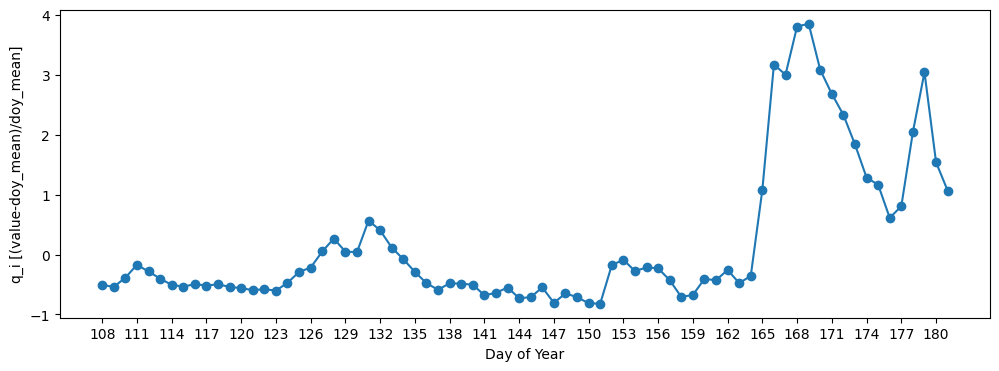

In [24]:
plt.figure(figsize=(12,4))
plt.plot(m_t["day_of_year"], m_t[1998], '-o')
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.show()
#Montague years worth correlating: 1998, 2004, 2021(?), 2018(?)

In [25]:
t_t = thom_anoms.transpose()
t_t.reset_index(inplace=True)
t_t

year,day_of_year,1991,1992,1993,1994,1996,1997,1998,1999,2000,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,108,-0.461100,-0.548504,0.982341,1.105013,0.940538,-0.230354,-0.533608,-0.652736,-0.317865,...,-0.537470,0.092867,0.020274,0.635099,-0.078356,-0.431943,-3.272445e-01,-0.250619,-0.020957,-0.542987
1,109,-0.466620,-0.462521,1.039322,1.171358,1.210225,0.100739,-0.496653,-0.627855,-0.337720,...,-0.582126,0.065774,0.067418,0.625000,-0.204479,-0.471991,-1.753883e-01,-0.252772,-0.123850,-0.545297
2,110,-0.408550,-0.404370,0.965633,1.165786,0.928384,0.633414,-0.449700,-0.623333,-0.306302,...,-0.552621,0.044634,0.010614,0.635504,-0.243996,-0.412521,8.879134e-07,-0.279155,-0.163647,-0.568320
3,111,-0.392938,-0.400255,0.864822,0.995199,0.879287,0.748086,-0.259775,-0.618803,-0.336169,...,-0.599177,0.040958,-0.103327,0.844809,-0.403139,-0.455425,2.574179e-02,-0.426762,-0.191255,-0.556001
4,112,0.074757,-0.246703,0.761642,0.796581,0.721915,0.730469,-0.218846,-0.614473,-0.380224,...,-0.565793,0.041613,-0.251765,0.916786,-0.409677,-0.364962,-1.674975e-01,-0.411772,-0.231415,-0.486264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,177,-0.608745,-0.084607,-0.177181,NaN,0.171299,0.119628,0.563767,-0.721719,-0.342989,...,-0.597073,0.579486,-0.612524,0.052823,-0.694972,-0.617223,-6.294968e-01,0.032238,0.554904,0.056979
70,178,-0.588390,-0.220233,-0.450719,NaN,-0.085041,0.054250,0.961730,-0.725326,-0.225051,...,-0.673635,0.600424,-0.695832,0.202590,-0.710492,-0.687560,-6.339091e-01,0.487123,0.444232,-0.492783
71,179,-0.575588,-0.361641,-0.562924,-0.278865,-0.030695,-0.299630,2.310499,-0.765204,0.087186,...,-0.746165,0.108051,-0.521854,0.458378,-0.740266,-0.724287,-7.061996e-01,0.927219,0.268295,-0.597803
72,180,-0.563503,-0.438679,-0.418357,-0.319682,-0.058201,-0.590446,2.161472,-0.565364,0.098634,...,-0.801733,-0.145531,0.086751,0.174510,-0.742041,-0.694755,-7.926998e-01,1.163839,-0.224235,-0.585664


In [26]:
h_t = holyoke_anoms.transpose()
h_t.reset_index(inplace=True)
h_t

year,day_of_year,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,108,0.073224,0.056624,-0.420224,-0.616354,1.188701,0.483390,-0.553400,-0.348579,0.860243,...,-0.548156,0.191641,0.057142,0.785252,-0.065221,-0.439927,-0.268693,-0.194776,0.007572,-0.498686
1,109,-0.079927,-0.107190,-0.437122,-0.602693,1.147732,0.518288,-0.537870,-0.251749,0.784312,...,-0.570979,0.212634,0.149582,0.825256,-0.180595,-0.447693,-0.081295,-0.159935,-0.075821,-0.513428
2,110,-0.272711,-0.121709,-0.395119,-0.581856,1.211238,0.623779,-0.508560,-0.290906,0.683809,...,-0.536583,0.196523,0.098384,0.867651,-0.220475,-0.369646,0.124573,-0.205145,-0.105803,-0.545294
3,111,-0.312558,-0.103510,-0.291188,-0.611414,1.346098,0.767543,-0.375045,-0.290716,0.542449,...,-0.583698,0.175440,-0.052576,1.084020,-0.395146,-0.438476,0.129483,-0.368492,-0.162673,-0.513271
4,112,-0.257136,-0.154332,-0.215710,-0.657901,1.336056,0.918873,-0.302491,-0.361675,0.516189,...,-0.535390,0.167297,-0.210379,1.173460,-0.379616,-0.317234,-0.096245,-0.339196,-0.201607,-0.428810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,177,-0.231827,-0.500296,-0.211002,0.404561,-0.477256,0.245452,0.044217,-0.504381,1.507128,...,-0.609761,0.552664,-0.617731,0.079607,-0.694723,-0.583660,-0.614619,0.054142,0.464713,-0.079891
70,178,-0.328385,-0.464331,-0.236972,0.909888,-0.563942,0.108049,-0.000663,-0.503563,1.147969,...,-0.659753,0.468523,-0.696774,0.256793,-0.720270,-0.663059,-0.599035,0.405077,0.336123,-0.534469
71,179,-0.395430,-0.597962,-0.343263,2.080931,-0.538342,-0.045761,0.036496,-0.486982,0.645499,...,-0.704337,-0.000822,-0.481401,0.472137,-0.741708,-0.702752,-0.713641,0.827184,0.186382,-0.596711
72,180,-0.662115,-0.688522,-0.220822,2.396002,-0.724599,-0.363059,-0.009402,-0.240475,0.411827,...,-0.745193,-0.213351,0.017005,0.172470,-0.745821,-0.668113,-0.783097,1.026845,-0.295705,-0.591419


In [27]:
h_t.to_csv("holyoke_t.csv", index=False)
m_t.to_csv("montague_t.csv", index=False)
t_t.to_csv("thompsonville_t.csv", index=False)

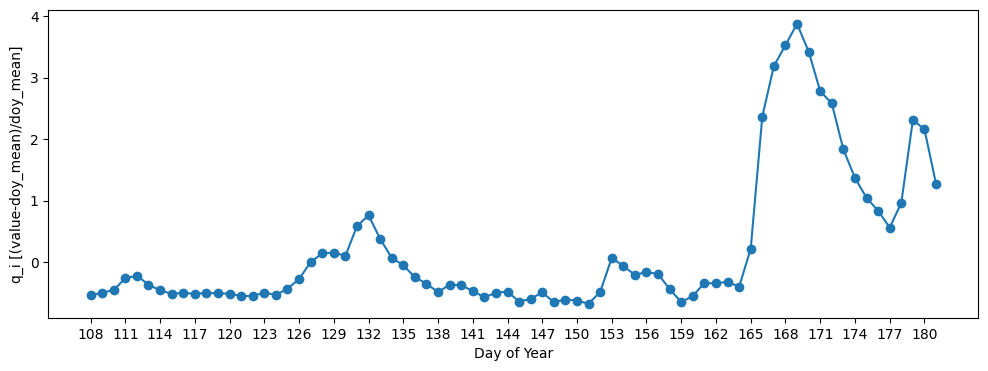

In [28]:
plt.figure(figsize=(12,4))
plt.plot(t_t["day_of_year"], t_t[1998], '-o')
plt.xticks(t_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.show()
#years worth correlating: 1998, 2004, 2021(?), 2018(?)

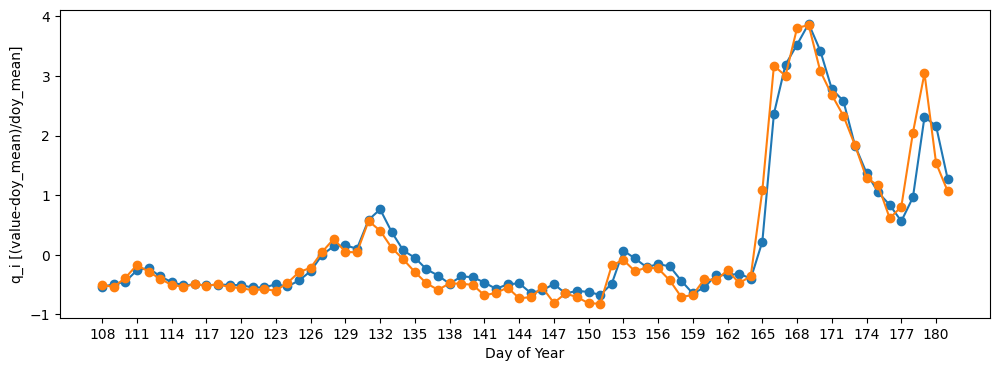

In [29]:
plt.figure(figsize=(12,4))
plt.plot(t_t["day_of_year"], t_t[1998], '-o')
plt.plot(m_t["day_of_year"], m_t[1998], '-o')
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.show()
#years worth correlating: 1998, 2004, 2021(?), 2018(?)

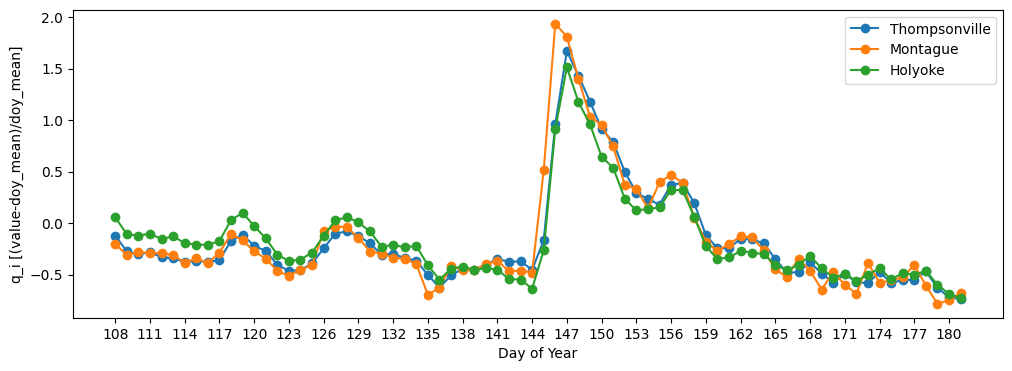

In [30]:
plt.figure(figsize=(12,4))
plt.plot(t_t["day_of_year"], t_t[2004], '-o', label="Thompsonville")
plt.plot(m_t["day_of_year"], m_t[2004], '-o', label="Montague")
plt.plot(h_t["day_of_year"], h_t[2004], '-o', label="Holyoke")
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
#years worth correlating: 1998, 2004, 2021(?), 2018(?)

Correlation with lag 0: 0.9343743866581897
Highest correlation lag achieved: -1 day(s)
Correlation at lag of -1 day(s): 0.9455546718999258


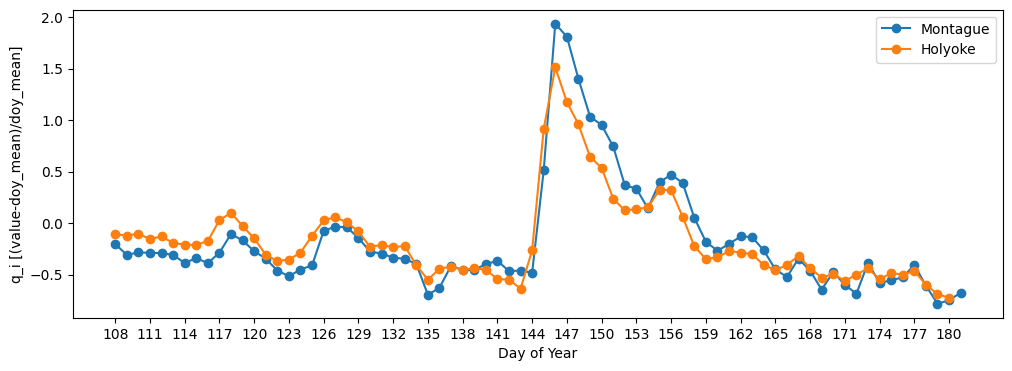

This suggests one day of lag between Montague and Holyoke in 2004.


In [31]:
mon_hol_corr = m_t[2004].corr(h_t[2004])
print(f"Correlation with lag 0: {mon_hol_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_h = h_t[2004].shift(lag)
    correlations[lag] = m_t.iloc[5:-5].loc[:, 2004].corr(shifted_h.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(12,4))
plt.plot(m_t["day_of_year"], m_t[2004], '-o', label="Montague")
plt.plot(h_t["day_of_year"], h_t[2004].shift(-1), '-o', label="Holyoke")
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
print("This suggests one day of lag between Montague and Holyoke in 2004.")

Correlation with lag 0: 0.9660774231165771
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.9685954777619868


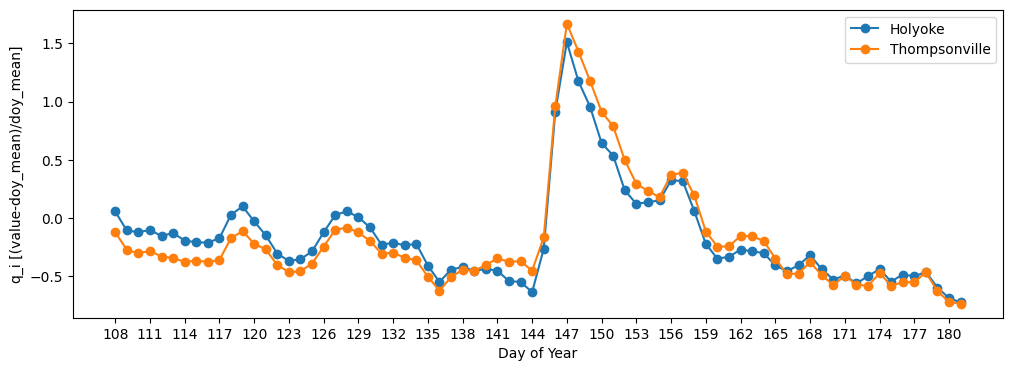

This suggests less than a day of lag between Holyoke and Thompsonville in 2004.


In [32]:
hol_thom_corr = h_t[2004].corr(t_t[2004])
print(f"Correlation with lag 0: {hol_thom_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_t = t_t[2004].shift(lag)
    correlations[lag] = h_t.iloc[5:-5].loc[:, 2004].corr(shifted_t.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(12,4))
plt.plot(h_t["day_of_year"], h_t[2004], '-o', label="Holyoke")
plt.plot(t_t["day_of_year"], t_t[2004].shift(0), '-o', label="Thompsonville")
plt.xticks(h_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
print("This suggests less than a day of lag between Holyoke and Thompsonville in 2004.")

Correlation with lag 0: 0.9752011539786698
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.9749124556980108


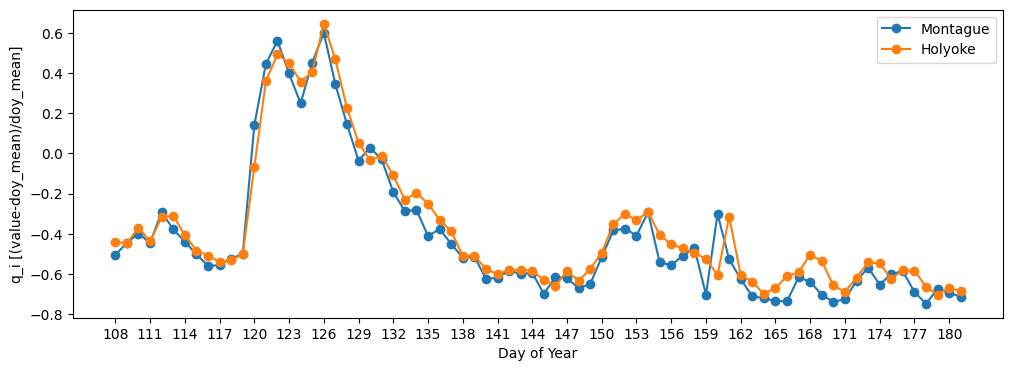

This suggests less than a day of lag between Montague and Holyoke in 2021.


In [33]:
year = 2021
mon_hol_corr = m_t[year].corr(h_t[year])
print(f"Correlation with lag 0: {mon_hol_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_h = h_t[year].shift(lag)
    correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_h.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(12,4))
plt.plot(m_t["day_of_year"], m_t[year], '-o', label="Montague")
plt.plot(h_t["day_of_year"], h_t[year].shift(target_lag), '-o', label="Holyoke")
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
print(f"This suggests less than a day of lag between Montague and Holyoke in {year}.")

Correlation with lag 0: 0.9911926402345306
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.9909560744634586


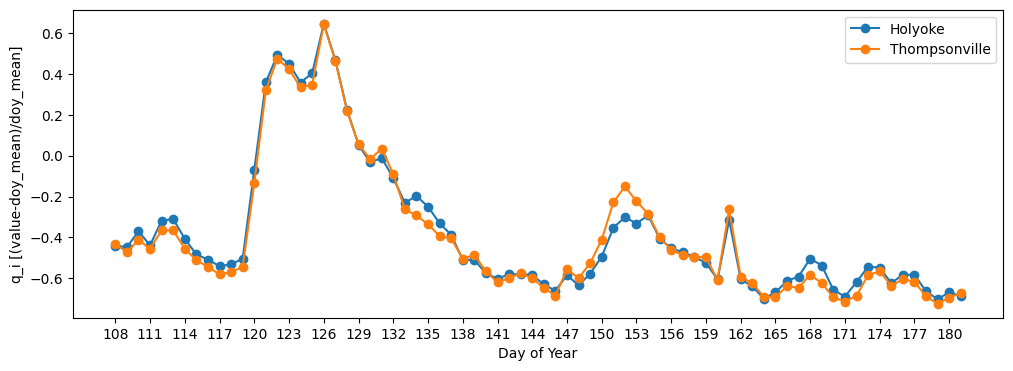

This suggests less than a day of lag between Holyoke and Thompsonville in 2021.


In [34]:
year = 2021
hol_thom_corr = h_t[year].corr(t_t[year])
print(f"Correlation with lag 0: {hol_thom_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_t = t_t[year].shift(lag)
    correlations[lag] = h_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(12,4))
plt.plot(h_t["day_of_year"], h_t[year], '-o', label="Holyoke")
plt.plot(t_t["day_of_year"], t_t[year].shift(target_lag), '-o', label="Thompsonville")
plt.xticks(h_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
print(f"This suggests less than a day of lag between Holyoke and Thompsonville in {year}.")

Correlation with lag 0: 0.9848660505606265
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.9882606081247309


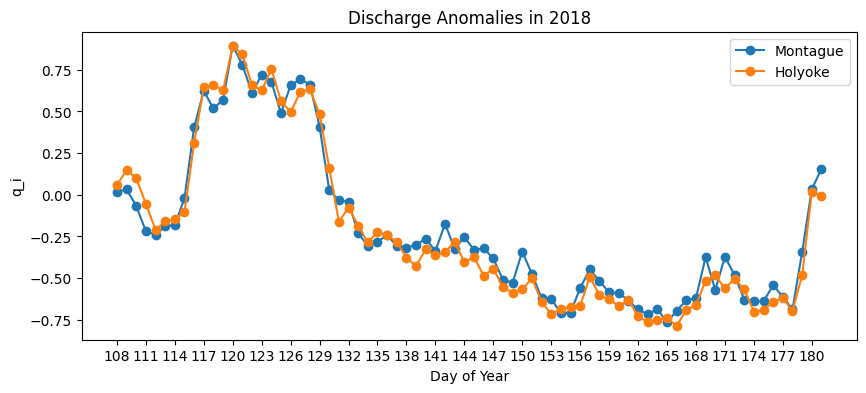

This suggests less than a day of lag between Montague and Holyoke in 2018.


In [47]:
year = 2018
mon_hol_corr = m_t[year].corr(h_t[year])
print(f"Correlation with lag 0: {mon_hol_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_h = h_t[year].shift(lag)
    correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_h.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(10,4))
plt.plot(m_t["day_of_year"], m_t[year], '-o', label="Montague")
plt.plot(h_t["day_of_year"], h_t[year].shift(target_lag), '-o', label="Holyoke")
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i")
plt.title("Discharge Anomalies in 2018")
plt.legend()
plt.show()
print(f"This suggests less than a day of lag between Montague and Holyoke in {year}.")

Correlation with lag 0: 0.8933985138071391
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.8846241119089892


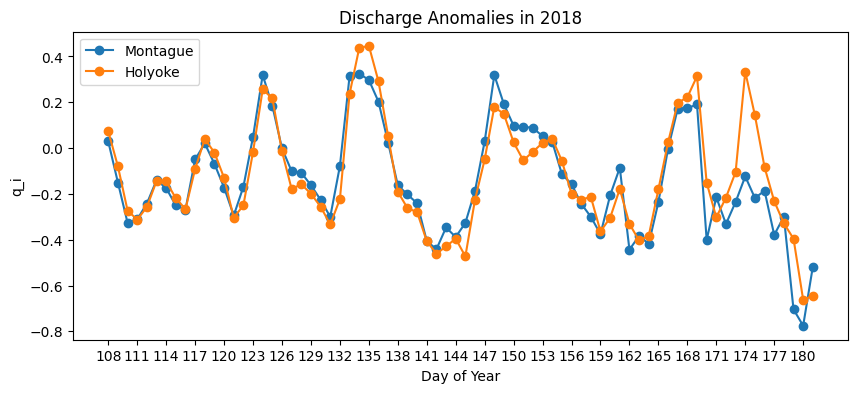

This suggests less than a day of lag between Montague and Holyoke in 2003.


In [49]:
year = 2003
mon_hol_corr = m_t[year].corr(h_t[year])
print(f"Correlation with lag 0: {mon_hol_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_h = h_t[year].shift(lag)
    correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_h.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(10,4))
plt.plot(m_t["day_of_year"], m_t[year], '-o', label="Montague")
plt.plot(h_t["day_of_year"], h_t[year].shift(target_lag), '-o', label="Holyoke")
plt.xticks(m_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i")
plt.title("Discharge Anomalies in 2018")
plt.legend()
plt.show()
print(f"This suggests less than a day of lag between Montague and Holyoke in {year}.")

Correlation with lag 0: 0.994594706137241
Highest correlation lag achieved: 0 day(s)
Correlation at lag of 0 day(s): 0.9956300930235101


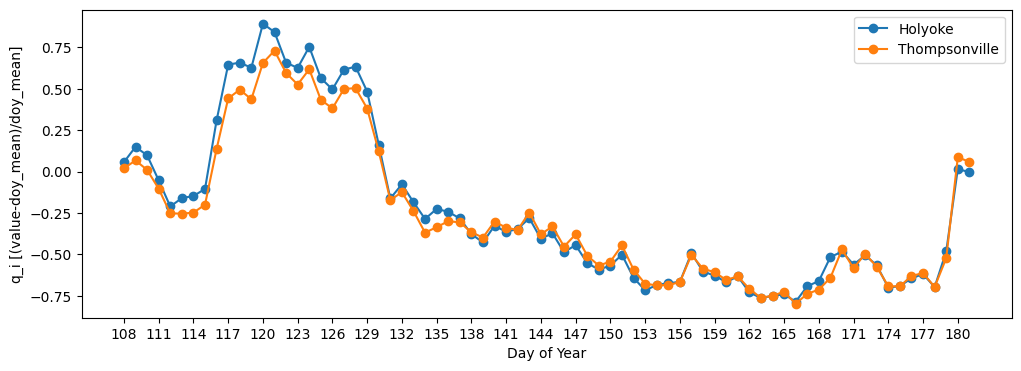

This suggests less than a day of lag between Holyoke and Thompsonville in 2018.


In [36]:
year = 2018
hol_thom_corr = h_t[year].corr(t_t[year])
print(f"Correlation with lag 0: {hol_thom_corr}")

lags = range(-5, 5)
correlations = {}

for lag in lags:
    shifted_t = t_t[year].shift(lag)
    correlations[lag] = h_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])

target_lag = max(correlations, key=correlations.get)
print(f"Highest correlation lag achieved: {target_lag} day(s)")
print(f"Correlation at lag of {target_lag} day(s): {correlations[target_lag]}")

plt.figure(figsize=(12,4))
plt.plot(h_t["day_of_year"], h_t[year], '-o', label="Holyoke")
plt.plot(t_t["day_of_year"], t_t[year].shift(target_lag), '-o', label="Thompsonville")
plt.xticks(h_t["day_of_year"][::3])
plt.xlabel("Day of Year")
plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
plt.legend()
plt.show()
print(f"This suggests less than a day of lag between Holyoke and Thompsonville in {year}.")

In [37]:
for year in range(2003, 2026):
    mon_hol_corr = m_t[year].corr(h_t[year])
    hol_thom_corr = h_t[year].corr(t_t[year])
    print(f"Correlation with lag 0, year {year}: {hol_thom_corr}")
    print(f"Correlation with lag 0, year {year}: {mon_hol_corr} \n")
    
    lags = range(-5, 5)
    correlations1 = {}
    correlations2 = {}
    
    for lag in lags:
        shifted_h = h_t[year].shift(lag)
        correlations1[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_h.iloc[5:-5])
        shifted_t = t_t[year].shift(lag)
        correlations2[lag] = h_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
    
    target_lag1 = max(correlations1, key=correlations1.get)
    target_lag2 = max(correlations2, key=correlations2.get)
    print(f"M-H Highest correlation lag achieved for year {year}: {target_lag1} day(s)")
    print(f"M-H Correlation at lag of {target_lag1} day(s) in {year}: {correlations1[target_lag]}\n")

    print(f"H-T Highest correlation lag achieved for year {year}: {target_lag2} day(s)")
    print(f"H-T Correlation at lag of {target_lag2} day(s) in {year}: {correlations2[target_lag]}")
    print("\n --------------------------------------------------------------- \n")

Correlation with lag 0, year 2003: 0.8763357689466593
Correlation with lag 0, year 2003: 0.8933985138071391 

M-H Highest correlation lag achieved for year 2003: 0 day(s)
M-H Correlation at lag of 0 day(s) in 2003: 0.8846241119089892

H-T Highest correlation lag achieved for year 2003: 0 day(s)
H-T Correlation at lag of 0 day(s) in 2003: 0.8626595098993204

 --------------------------------------------------------------- 

Correlation with lag 0, year 2004: 0.9660774231165771
Correlation with lag 0, year 2004: 0.9343743866581897 

M-H Highest correlation lag achieved for year 2004: -1 day(s)
M-H Correlation at lag of -1 day(s) in 2004: 0.9375296420467701

H-T Highest correlation lag achieved for year 2004: 0 day(s)
H-T Correlation at lag of 0 day(s) in 2004: 0.9685954777619868

 --------------------------------------------------------------- 

Correlation with lag 0, year 2005: 0.9829012055632765
Correlation with lag 0, year 2005: 0.9647382290125036 

M-H Highest correlation lag achiev

In [38]:
years_by_target_lag = defaultdict(list)
for year in range(1993, 2026):
    if year in m_t.columns and year in t_t.columns:
        mon_thom_corr = m_t[year].corr(t_t[year])
        print(f"Correlation with lag 0, year {year}: {mon_thom_corr}")
        
        lags = range(-5, 5)
        correlations = {}
        
        for lag in lags:
            shifted_t = t_t[year].shift(lag)
            correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
        
        target_lag = max(correlations, key=correlations.get)
        years_by_target_lag[target_lag].append(year)
        print(f"T-M Highest correlation lag achieved for year {year}: {target_lag} day(s)")
        print(f"T-M Correlation at lag of {target_lag} day(s) in {year}: {correlations[target_lag]}")
        print("\n --------------------------------------------------------------- \n")
    else:
        print(f"{year} missing from Montague, skipping...\n" if (year not in m_t.columns) else f"{year} missing from Thompsonville, skipping...\n")

Correlation with lag 0, year 1993: 0.9735013210410508
T-M Highest correlation lag achieved for year 1993: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1993: 0.9734044619283105

 --------------------------------------------------------------- 

Correlation with lag 0, year 1994: 0.9376199779844258
T-M Highest correlation lag achieved for year 1994: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1994: 0.9253501786831139

 --------------------------------------------------------------- 

1995 missing from Thompsonville, skipping...

Correlation with lag 0, year 1996: 0.9614637657411349
T-M Highest correlation lag achieved for year 1996: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1996: 0.9749224375014877

 --------------------------------------------------------------- 

Correlation with lag 0, year 1997: 0.9533044686086963
T-M Highest correlation lag achieved for year 1997: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1997: 0.9711612234528384

 ----------------------------

In [39]:
print(years_by_target_lag)

defaultdict(<class 'list'>, {-1: [1993, 1994, 1996, 1997, 1999, 2002, 2004, 2005, 2008, 2010, 2011, 2012, 2013, 2015, 2016, 2018, 2019, 2020, 2022, 2023, 2024], 0: [1998, 2000, 2001, 2003, 2006, 2007, 2009, 2014, 2017, 2021, 2025]})


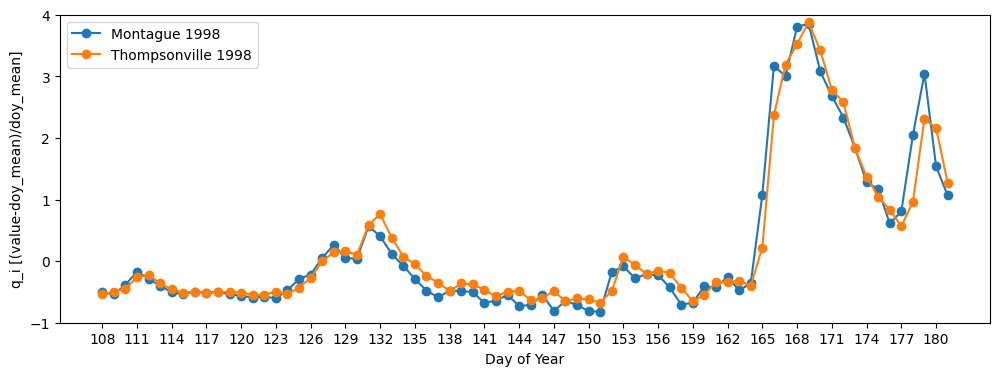

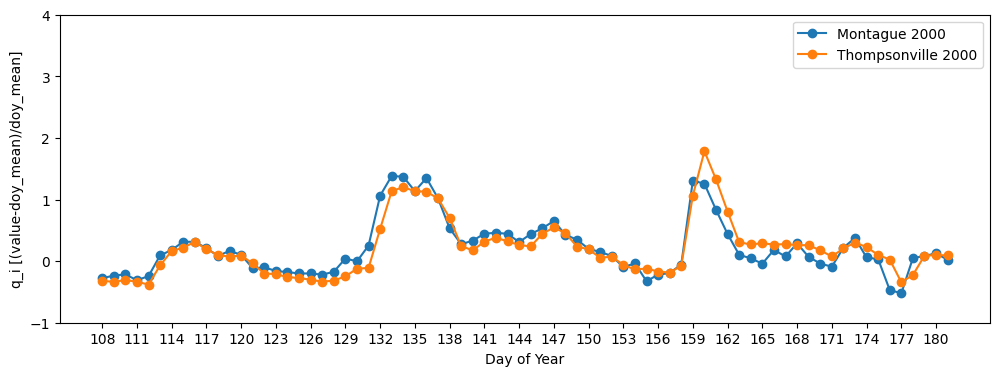

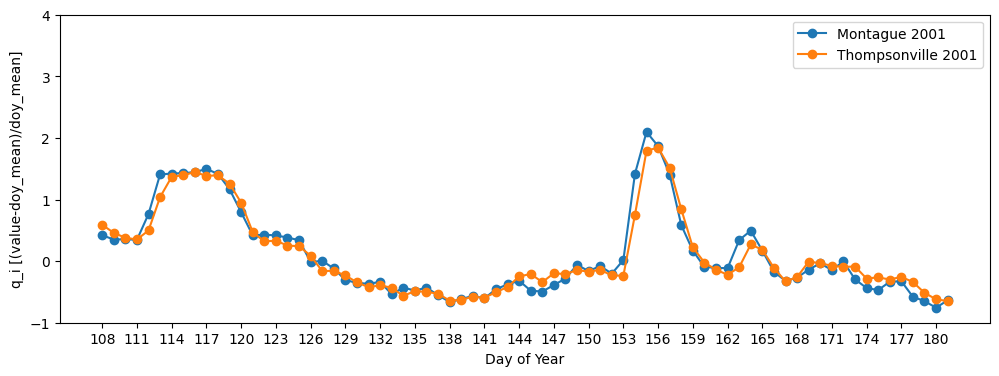

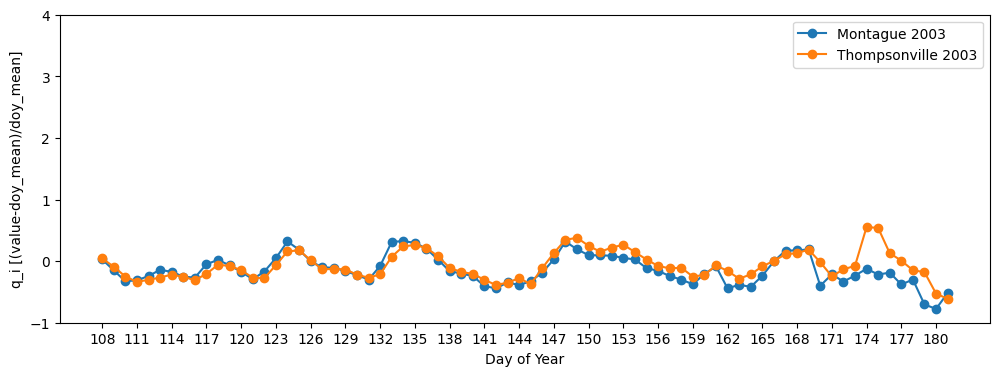

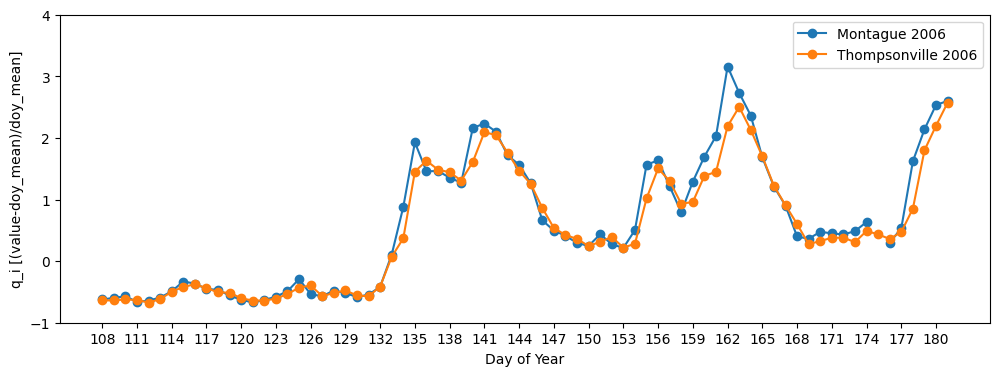

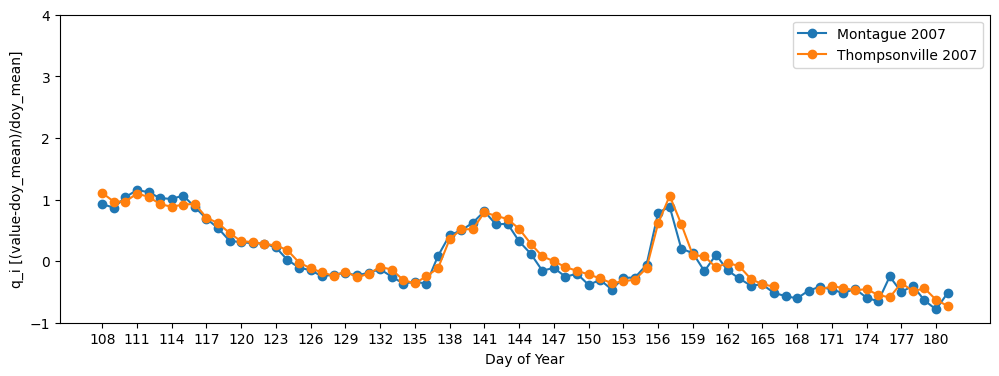

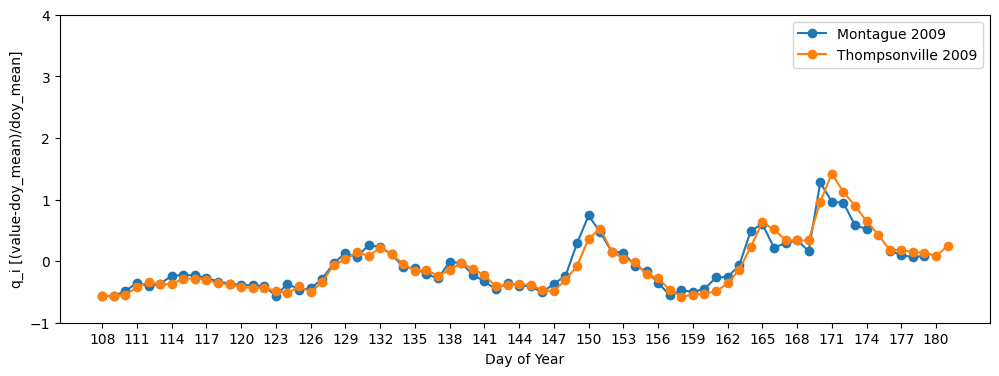

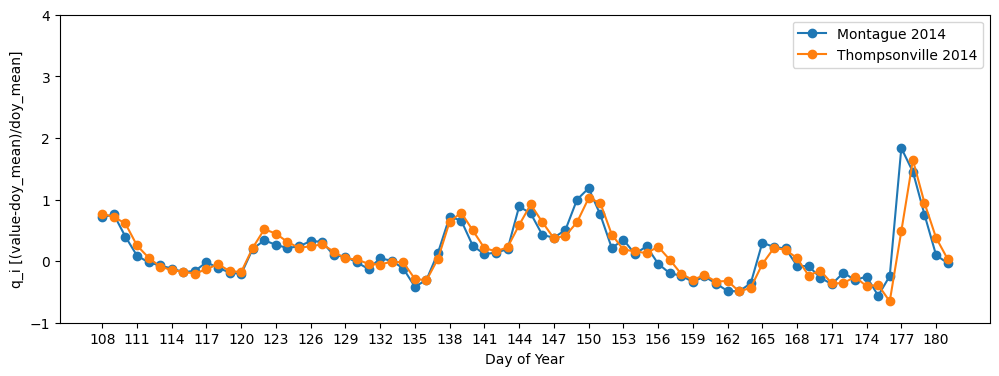

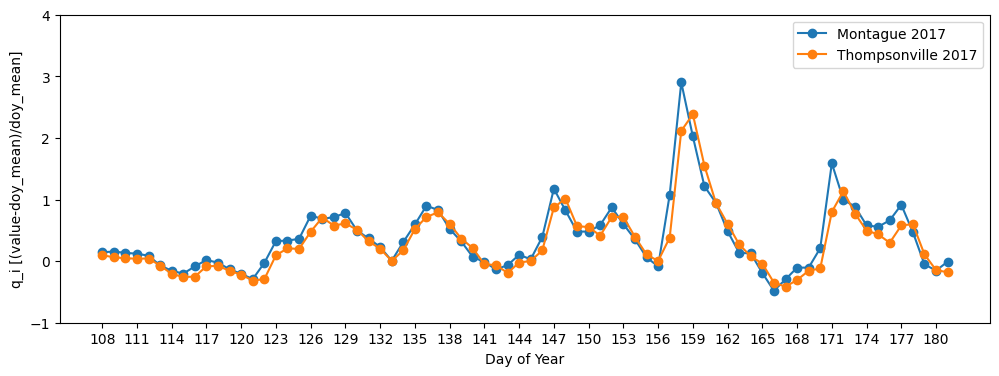

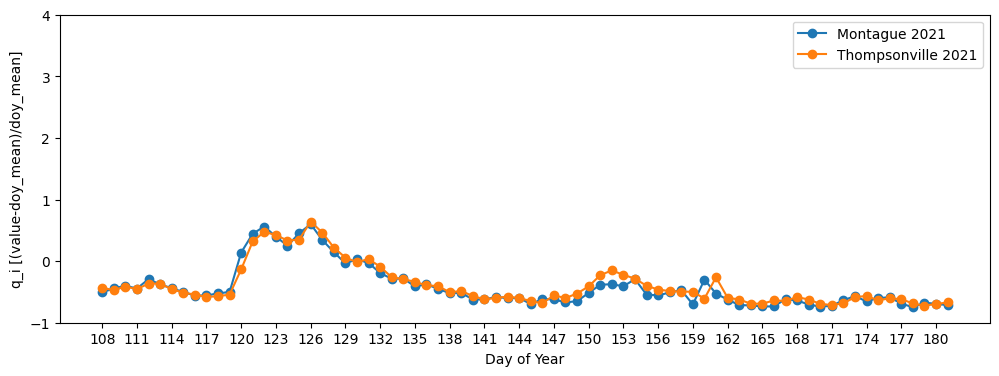

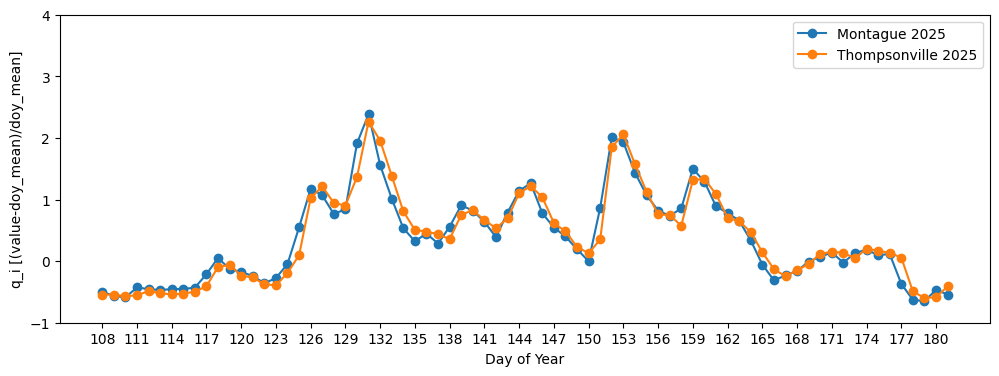

In [40]:
for year in years_by_target_lag[0]:
    plt.figure(figsize=(12,4))
    plt.plot(m_t["day_of_year"], m_t[year], '-o', label=f"Montague {year}")
    plt.plot(t_t["day_of_year"], t_t[year].shift(0), '-o', label=f"Thompsonville {year}")
    plt.xticks(m_t["day_of_year"][::3])
    plt.ylim(-1, 4) 
    plt.xlabel("Day of Year")
    plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
    plt.legend()
    plt.show()

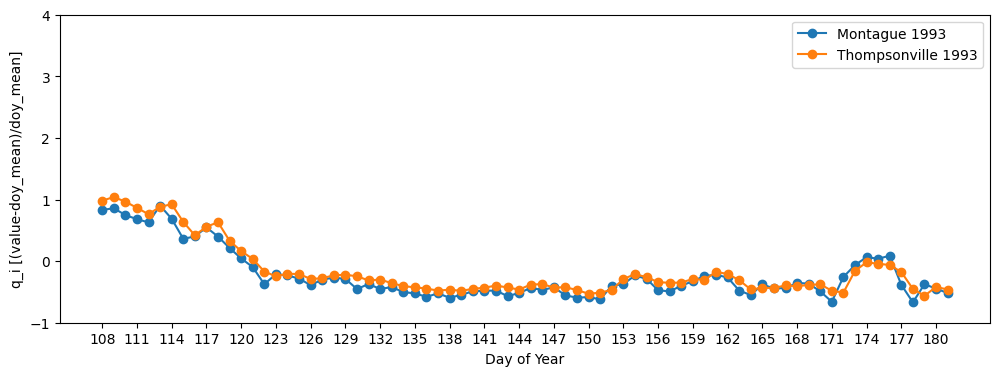

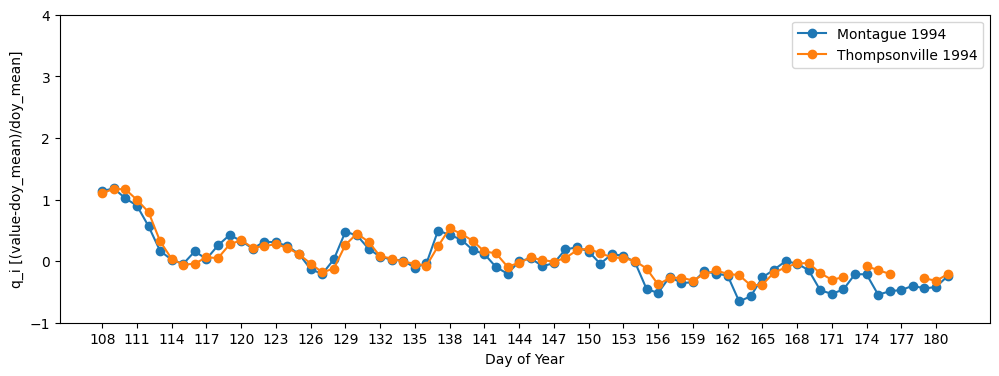

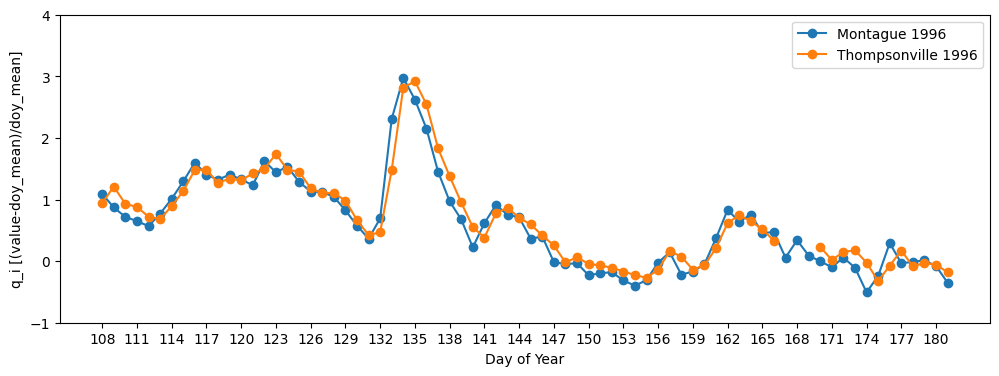

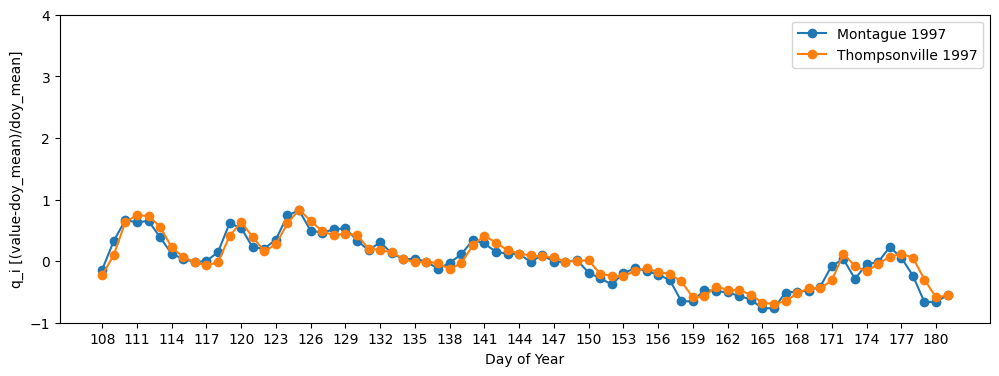

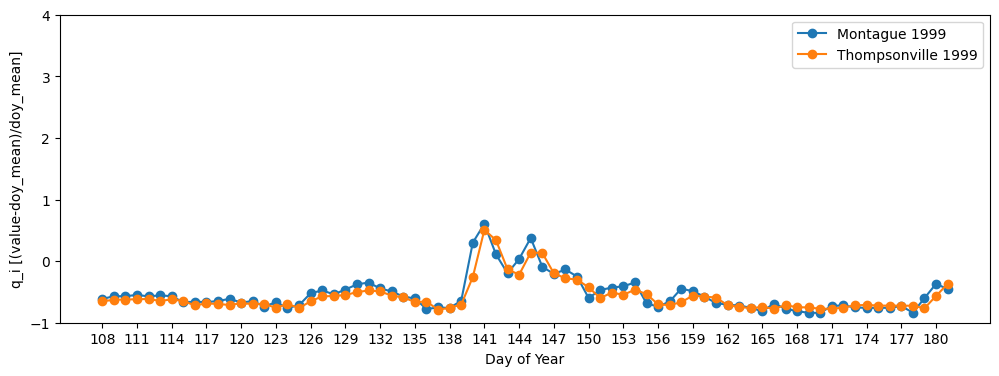

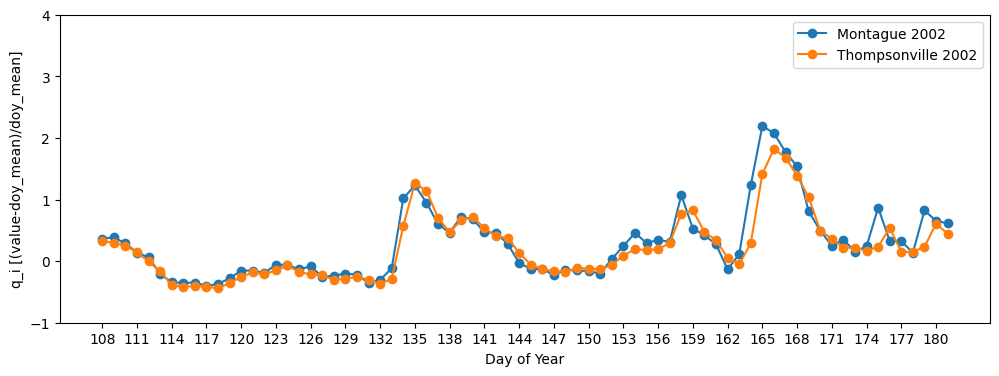

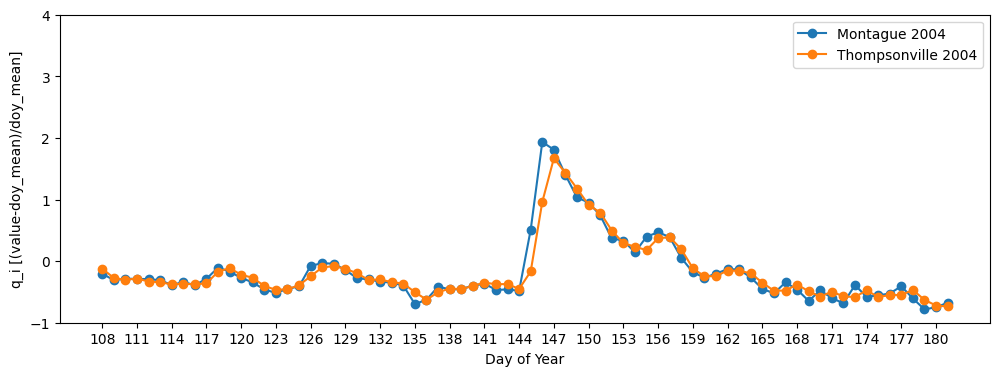

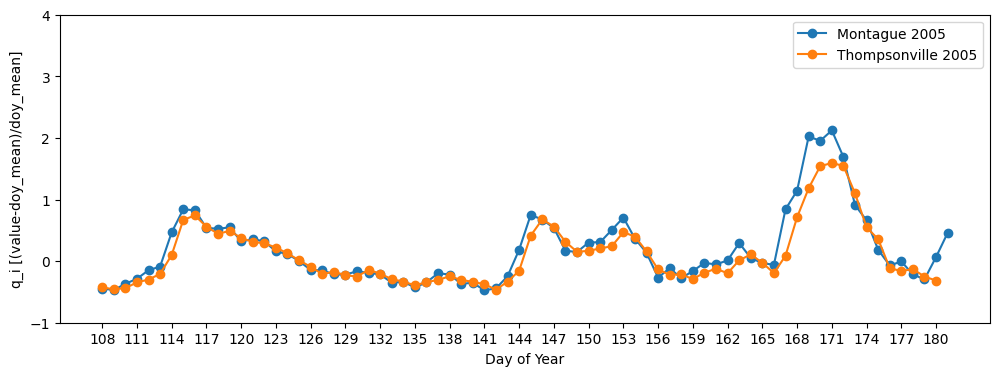

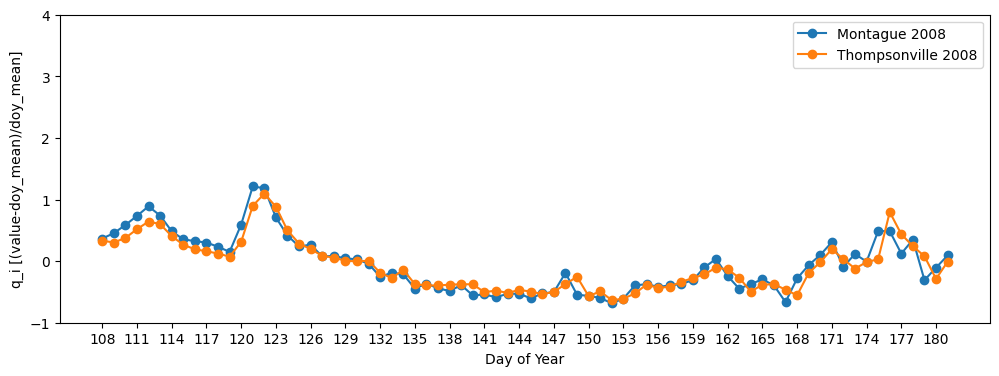

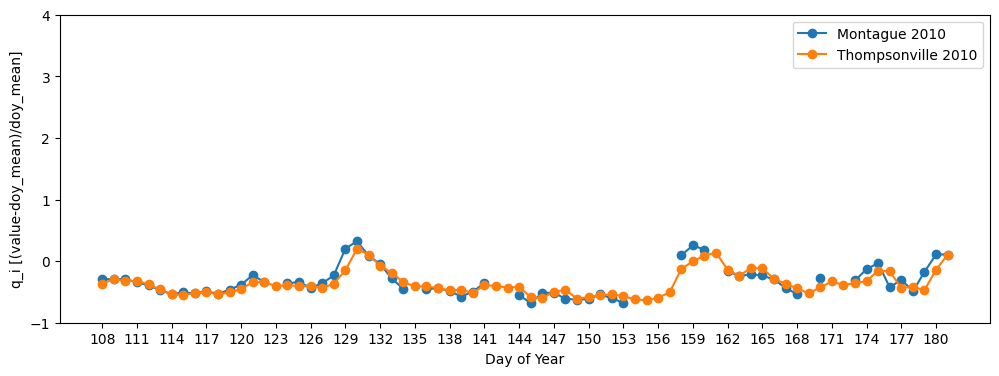

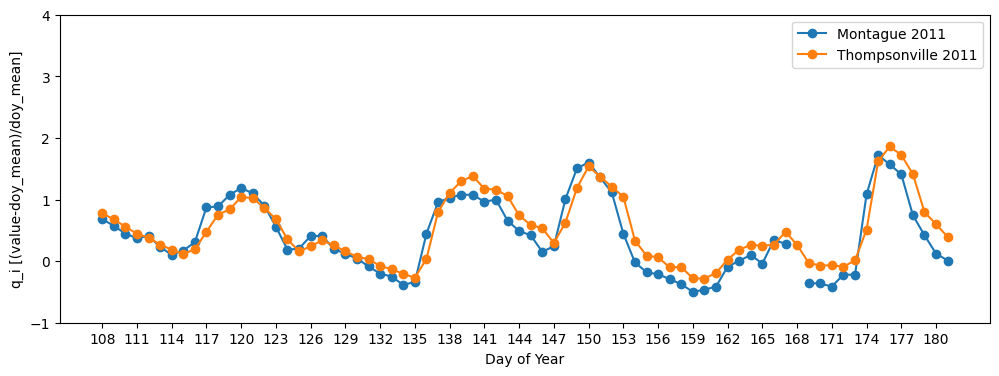

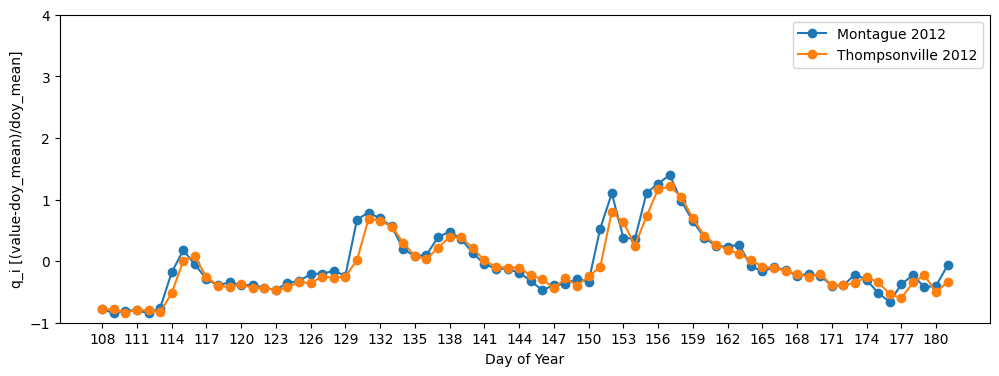

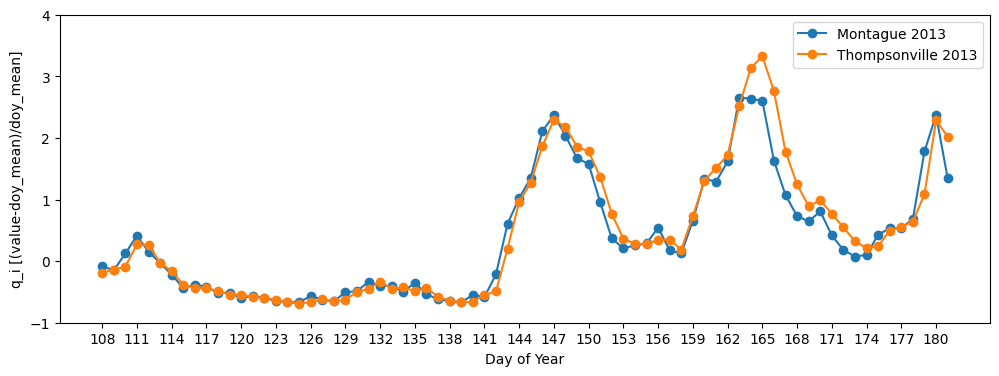

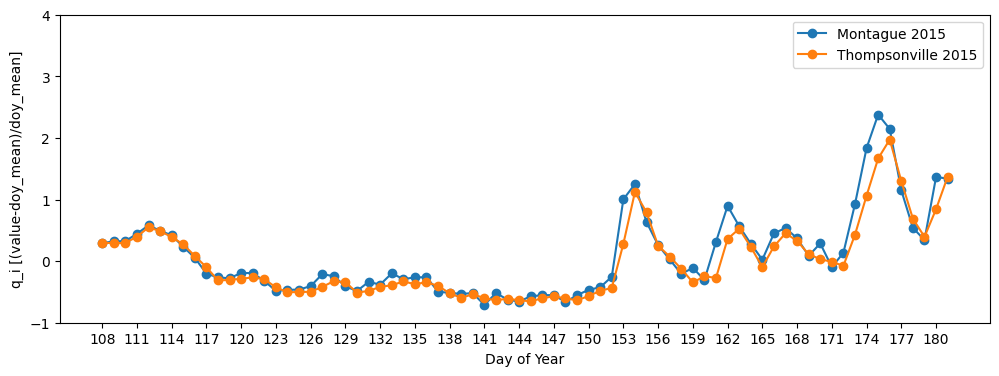

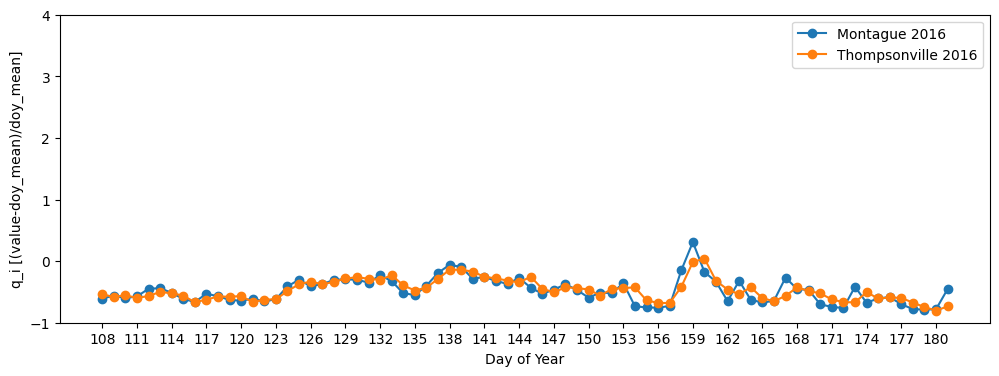

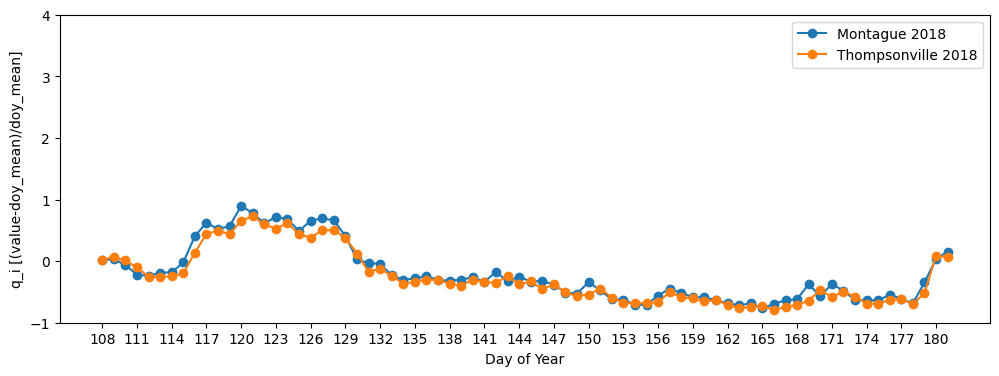

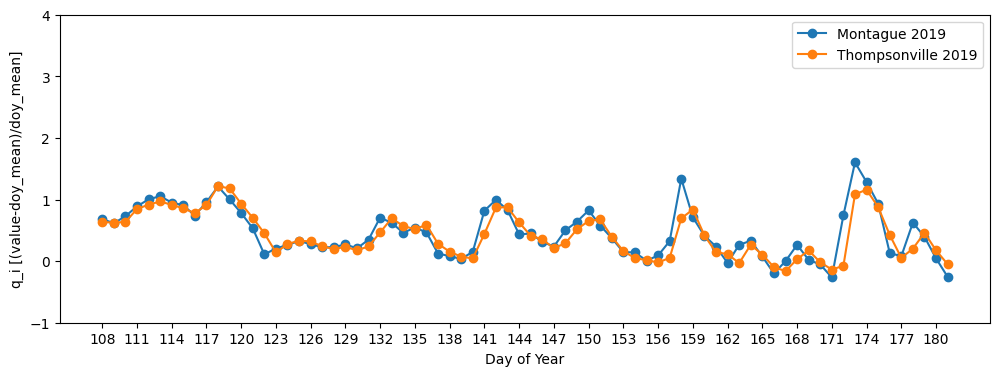

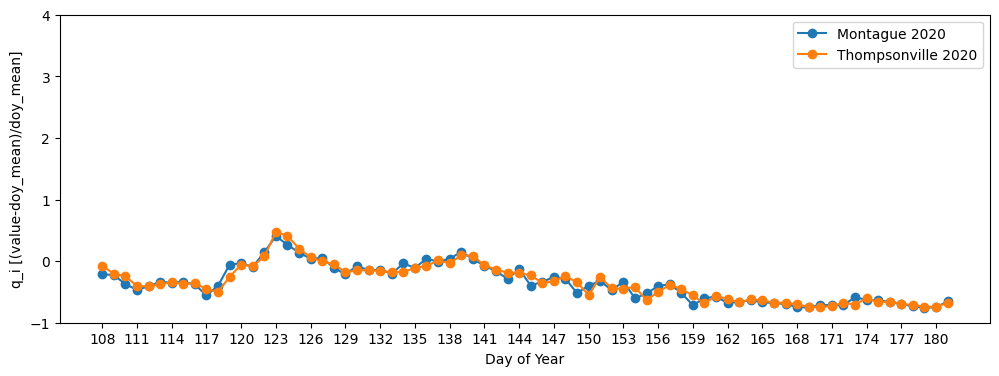

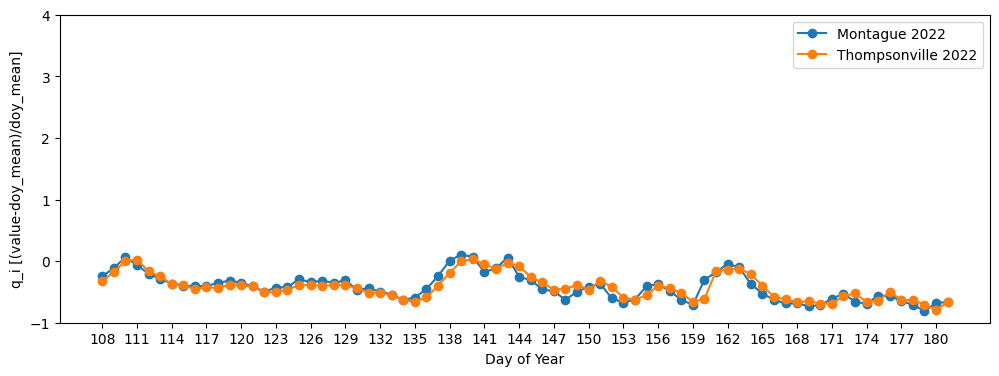

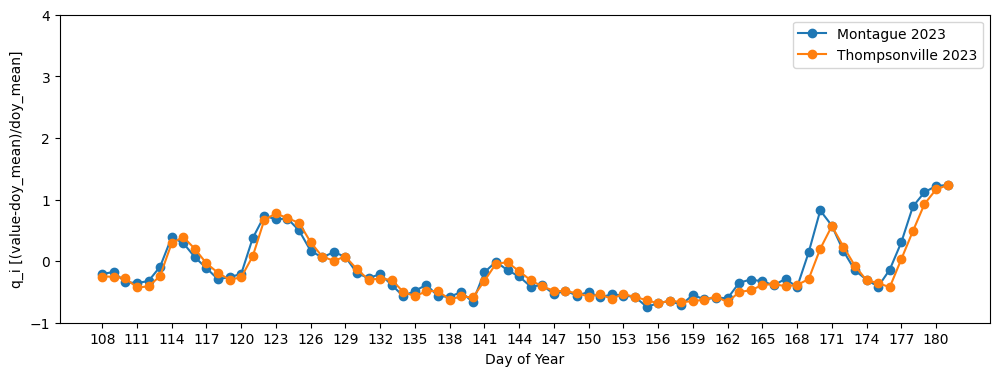

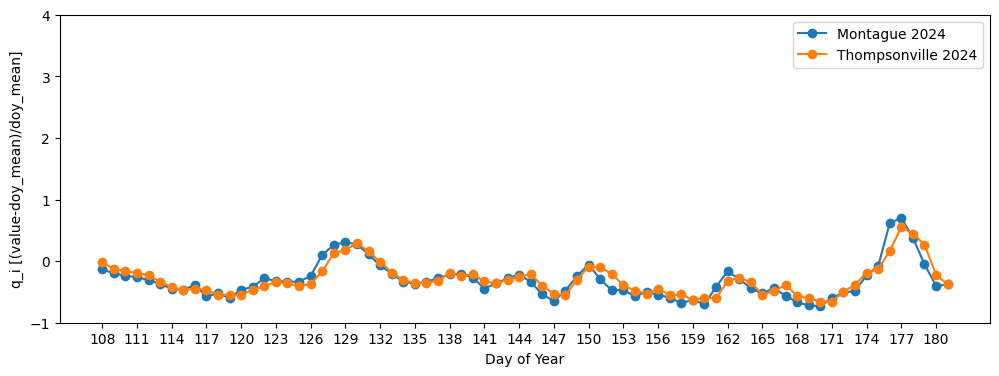

In [41]:
for year in years_by_target_lag[-1]:
    plt.figure(figsize=(12,4))
    plt.plot(m_t["day_of_year"], m_t[year], '-o', label=f"Montague {year}")
    plt.plot(t_t["day_of_year"], t_t[year].shift(0), '-o', label=f"Thompsonville {year}")
    plt.xticks(m_t["day_of_year"][::3])
    plt.ylim(-1, 4)
    plt.xlabel("Day of Year")
    plt.ylabel("q_i [(value-doy_mean)/doy_mean]")
    plt.legend()
    plt.show()

In [42]:
years_by_target_lag = defaultdict(list)
for year in range(1993, 2026):
    if year in m_t.columns and year in t_t.columns:
        mon_thom_corr = m_t[year].corr(t_t[year])
        print(f"Correlation with lag 0, year {year}: {mon_thom_corr}")
        
        lags = range(-5, 5)
        correlations = {}
        
        for lag in lags:
            shifted_t = t_t[year].shift(lag)
            correlations[lag] = m_t.iloc[5:-5].loc[:, year].corr(shifted_t.iloc[5:-5])
        
        target_lag = max(correlations, key=correlations.get)
        years_by_target_lag[target_lag].append(year)
        print(f"T-M Highest correlation lag achieved for year {year}: {target_lag} day(s)")
        print(f"T-M Correlation at lag of {target_lag} day(s) in {year}: {correlations[target_lag]}")
        print("\n --------------------------------------------------------------- \n")
    else:
        print(f"{year} missing from Montague, skipping...\n" if (year not in m_t.columns) else f"{year} missing from Thompsonville, skipping...\n")

Correlation with lag 0, year 1993: 0.9735013210410508
T-M Highest correlation lag achieved for year 1993: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1993: 0.9734044619283105

 --------------------------------------------------------------- 

Correlation with lag 0, year 1994: 0.9376199779844258
T-M Highest correlation lag achieved for year 1994: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1994: 0.9253501786831139

 --------------------------------------------------------------- 

1995 missing from Thompsonville, skipping...

Correlation with lag 0, year 1996: 0.9614637657411349
T-M Highest correlation lag achieved for year 1996: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1996: 0.9749224375014877

 --------------------------------------------------------------- 

Correlation with lag 0, year 1997: 0.9533044686086963
T-M Highest correlation lag achieved for year 1997: -1 day(s)
T-M Correlation at lag of -1 day(s) in 1997: 0.9711612234528384

 ----------------------------